# 1 Gradient descent methods

This part focuses on understanding the principles of a gradient descent algorithm. We expect to be able to answer questions such as: **why does this method work?** **Why/in which cases is this a good method?**

---

## 1.1 A simple quadratic function

We begin with a simple two-dimensional function, namely

$$
f(\mathbf{x}) = x_1^2 + x_2^2
$$

where $\mathbf{x} \in \mathbb{R}^2$,  
$\mathbf{x} = (x_1, x_2)^T$ (vectors are expressed as columns).  

It is easy to minimize this function numerically because it is a **convex function**.  Convex functions have a single minimum.

---

How to minimize a function $f(\mathbf{x})$ numerically?  

Let us begin with the previous function. Take the example source code you have included within this document and run it.  

The code performs a contour plot of $f(\mathbf{x}) = x_1^2 + x_2^2$ and draws the gradient of the function as arrows associated to the gradient.

The gradient of a function, $\nabla f$, points towards the direction in which the function increases with the highest possible slope.  

In other words, we follow the gradient direction in order to increase the value of the function at its highest rate.

1. Please, implement the previous algorithm with a constant $\alpha^k = 0.1$ parameter. Take an initial point $\mathbf{x}^0$ and perform at most 100 iterations. Try different starting points $\mathbf{x}^0$. Observe that the algorithm always converges (up to a certain precision) to the only minimum this function has. Observe that the more the iterations, the closer to the minimum.  Please, draw the path the gradient descent follows for each of the starting points $\mathbf{x}^0$ you have studied.

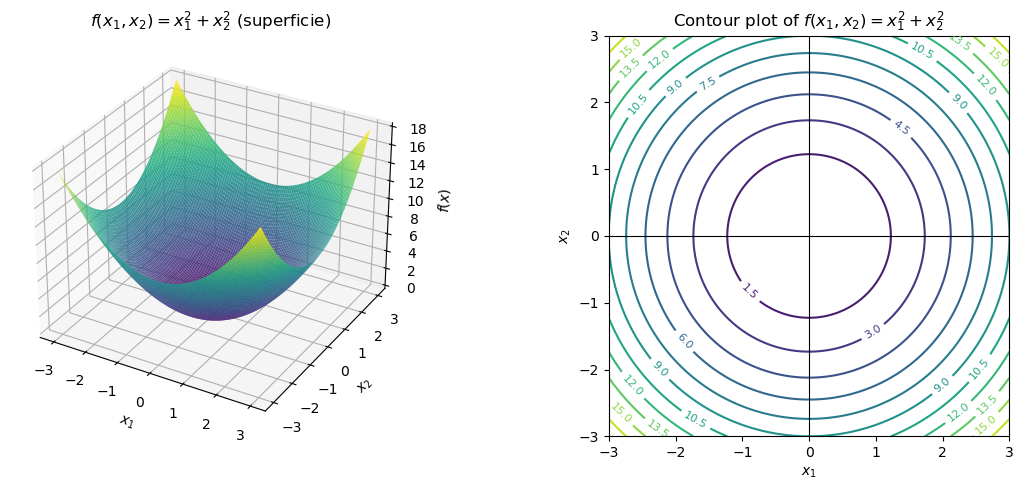

In [41]:
import numpy as np
import matplotlib.pyplot as pltimport 
import plotly.graph_objects as go
import matplotlib.pyplot as plt

R = 3.0        
N = 301       

x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(12, 5))

# Subplot 1: superfície 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, rstride=3, cstride=3, 
                 linewidth=0, antialiased=True, 
                 alpha=0.9, cmap="viridis")
ax1.set_title(r"$f(x_1,x_2)=x_1^2+x_2^2$ (superficie)")
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_zlabel(r"$f(x)$")

# Subplot 2: gràfic de contorn
ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(X, Y, Z, levels=15, cmap="viridis")
ax2.clabel(cs, inline=True, fontsize=8)
ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_title(r"Contour plot of $f(x_1,x_2)=x_1^2+x_2^2$")
ax2.axhline(0, linewidth=0.8, color="k")
ax2.axvline(0, linewidth=0.8, color="k")
ax2.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()



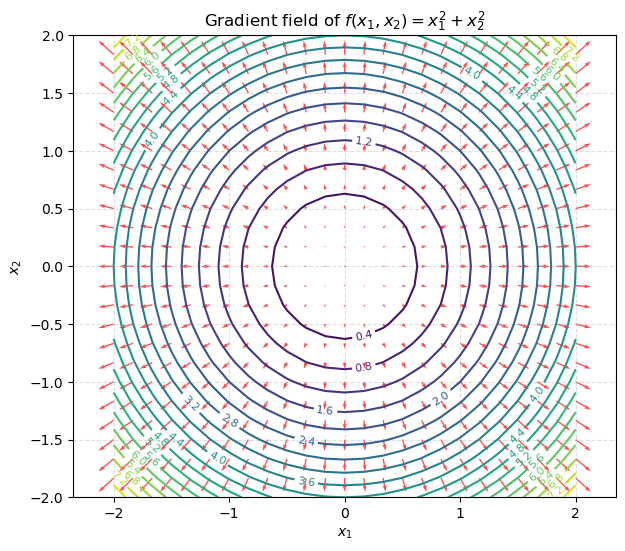

In [42]:
def f(x1, x2):
    return x1**2 + x2**2

def grad_f(x1, x2):
    return 2*x1, 2*x2

x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)


Z = f(X1, X2)
U, V = grad_f(X1, X2)


plt.figure(figsize=(7,6))
contours = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.quiver(X1, X2, U, V, color='red', alpha=0.7)

plt.title(r"Gradient field of $f(x_1,x_2)=x_1^2+x_2^2$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid(True, linestyle='--', alpha=0.4)
plt.axis("equal")
plt.show()

In [43]:
# Gradient descens method with constant learning rate

## definim el nou el gradient però ara que retorne un vector
def grad_f(x1, x2):
    return np.array([2*x1, 2*x2])

## definim el proces del grad descens 
def grad_desc_cte(x0, alpha,niter):
    xk = x0
    fpath = [x0]

    for i in range(0,niter):
        xk = xk - np.array([alpha,alpha]) * grad_f(xk[0], xk[1])
        fpath.append(xk)
    
    return(fpath)


fpath1 = grad_desc_cte(x0 = np.array([2,1]), alpha = 0.1, niter = 100)
fpath2 = grad_desc_cte(x0 = np.array([-2,1]), alpha = 0.1, niter = 100)
fpath3 = grad_desc_cte(x0 = np.array([2,-1]), alpha = 0.1, niter = 100)
fpath4 = grad_desc_cte(x0 = np.array([-2,-1]), alpha = 0.1, niter = 100)


print(fpath1)

[array([2, 1]), array([1.6, 0.8]), array([1.28, 0.64]), array([1.024, 0.512]), array([0.8192, 0.4096]), array([0.65536, 0.32768]), array([0.524288, 0.262144]), array([0.4194304, 0.2097152]), array([0.33554432, 0.16777216]), array([0.26843546, 0.13421773]), array([0.21474836, 0.10737418]), array([0.17179869, 0.08589935]), array([0.13743895, 0.06871948]), array([0.10995116, 0.05497558]), array([0.08796093, 0.04398047]), array([0.07036874, 0.03518437]), array([0.056295 , 0.0281475]), array([0.045036, 0.022518]), array([0.0360288, 0.0180144]), array([0.02882304, 0.01441152]), array([0.02305843, 0.01152922]), array([0.01844674, 0.00922337]), array([0.0147574, 0.0073787]), array([0.01180592, 0.00590296]), array([0.00944473, 0.00472237]), array([0.00755579, 0.00377789]), array([0.00604463, 0.00302231]), array([0.0048357 , 0.00241785]), array([0.00386856, 0.00193428]), array([0.00309485, 0.00154743]), array([0.00247588, 0.00123794]), array([0.0019807 , 0.00099035]), array([0.00158456, 0.000792

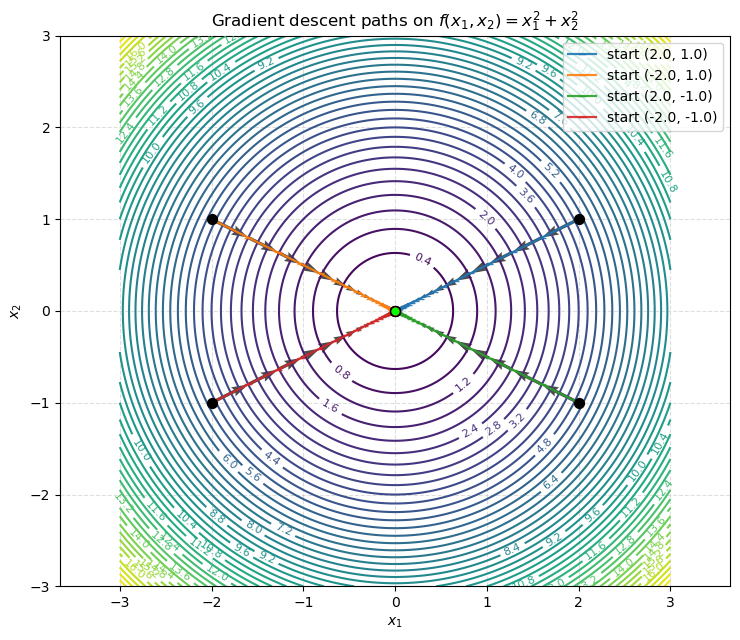

In [44]:
# Representació 

paths  = [fpath1, fpath2, fpath3, fpath4]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

# --- malla per al contorn ---
x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.005, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)

# mínim global
plt.scatter(0, 0, s=90, marker='.', color='lime', edgecolor='lime', zorder=4)

plt.title(r"Gradient descent paths on $f(x_1,x_2)=x_1^2+x_2^2$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

2. You may try other values of $\alpha$ such as $\alpha^k = 1$ and $\alpha^k = 2$. In this case the gradient descent performs poorly due to the too bigger steps. This shows you the importance of selecting an appropriate value for the step $\alpha_k$. There are many research works that have focused on this issue, but it is not the purpose of this lab to see how they work. Rather, we just will see some of their principles.


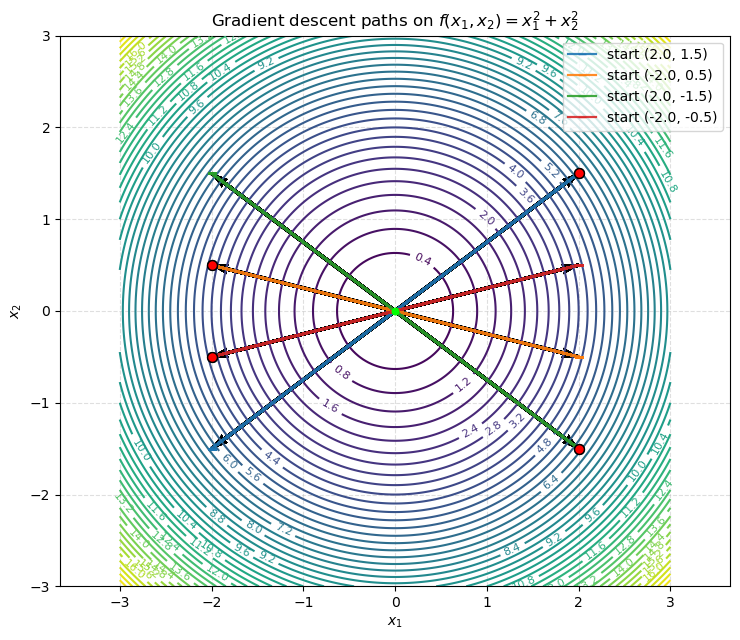

In [45]:
fpath5 = grad_desc_cte(x0 = np.array([2,1.5]), alpha = 1, niter = 100)
fpath6 = grad_desc_cte(x0 = np.array([-2,0.5]), alpha = 1, niter = 100)
fpath7 = grad_desc_cte(x0 = np.array([2,-1.5]), alpha = 1, niter = 100)
fpath8 = grad_desc_cte(x0 = np.array([-2,-0.5]), alpha = 1, niter = 100)

# Representació 

paths  = [fpath5, fpath6, fpath7, fpath8]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

# --- malla per al contorn ---
x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.005, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)

# mínim global
plt.scatter(0, 0, s=90, marker='.', color='lime', edgecolor='lime', zorder=4)

plt.title(r"Gradient descent paths on $f(x_1,x_2)=x_1^2+x_2^2$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


En el cas de que posem el valor de learning rate en $\alpha^k = 1$ no troba mai el valor del mínim perque la funció avança tota l'estona en la mateix proporció en la direcció del gradient i va iterant d'un punt al mateix quedant-se encallat

Ara veiem que passa si el learning rate es massa gran, per example $\alpha^k=2$

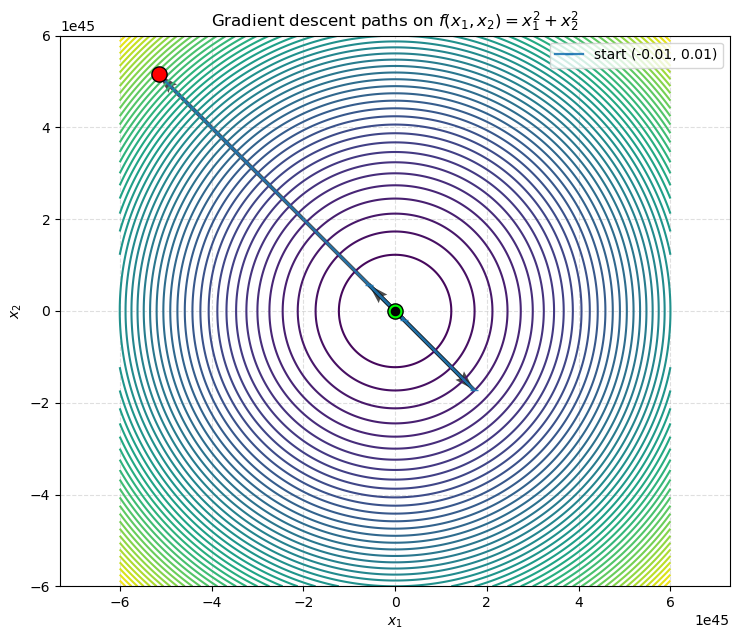

[array([-0.01,  0.01]), array([ 0.03, -0.03]), array([-0.09,  0.09]), array([ 0.27, -0.27]), array([-0.81,  0.81]), array([ 2.43, -2.43]), array([-7.29,  7.29]), array([ 21.87, -21.87]), array([-65.61,  65.61]), array([ 196.83, -196.83]), array([-590.49,  590.49]), array([ 1771.47, -1771.47]), array([-5314.41,  5314.41]), array([ 15943.23, -15943.23]), array([-47829.69,  47829.69]), array([ 143489.07, -143489.07]), array([-430467.21,  430467.21]), array([ 1291401.63, -1291401.63]), array([-3874204.89,  3874204.89]), array([ 11622614.67, -11622614.67]), array([-34867844.01000001,  34867844.01000001]), array([ 1.04603532e+08, -1.04603532e+08]), array([-3.13810596e+08,  3.13810596e+08]), array([ 9.41431788e+08, -9.41431788e+08]), array([-2.82429536e+09,  2.82429536e+09]), array([ 8.47288609e+09, -8.47288609e+09]), array([-2.54186583e+10,  2.54186583e+10]), array([ 7.62559748e+10, -7.62559748e+10]), array([-2.28767925e+11,  2.28767925e+11]), array([ 6.86303774e+11, -6.86303774e+11]), array

In [46]:
#fpath9 = grad_desc_cte(x0 = np.array([0.5, -0.5]), alpha = 2, niter = 100)
#fpath10 = grad_desc_cte(x0 = np.array([2,1]), alpha = 2, niter = 100)
fpath11 = grad_desc_cte(x0 = np.array([-0.01,0.01]), alpha = 2, niter = 100)


# Representació 

paths  = [ fpath11]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

# --- malla per al contorn ---
x1 = np.linspace(-6*10**45, 6*10**45, 500)
x2 = np.linspace(-6*10**45, 6*10**45, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=120, edgecolor='k', facecolor='lime',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=120, edgecolor='k', facecolor='red',   zorder=3)

# mínim global
plt.scatter(0, 0, s=140, marker='.', color='black', edgecolor='k', zorder=4)

plt.title(r"Gradient descent paths on $f(x_1,x_2)=x_1^2+x_2^2$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(fpath11)

Encara que es comence en un punt molt aprop del mínim, no s'assoleix perque el passos del gradient que dona son del doble del gradient i, va disparant-se.

### 1.2 A function with multiple minima

Consider now the following function:

$$
f(x_1, x_2) 
= x_1^2 \left(4 - 2.1x_1^2 + \frac{1}{3}x_1^4 \right)
\,+\, x_1 x_2 
\,+\, x_2^2 \left( -4 + 4x_2^2 \right)
$$

Plot a contour plot of the previous function within the range $x_1 \in [-2, 2]$ and $x_2 \in [-1, 1]$. This function is fundamentally more complex than the previous one because 
it is **not convex**, which means it has **several local minima**. Which minima will be found? Can you guess it? It will depend, in fact, on the initial value $\mathbf{x}^0$ you assign.

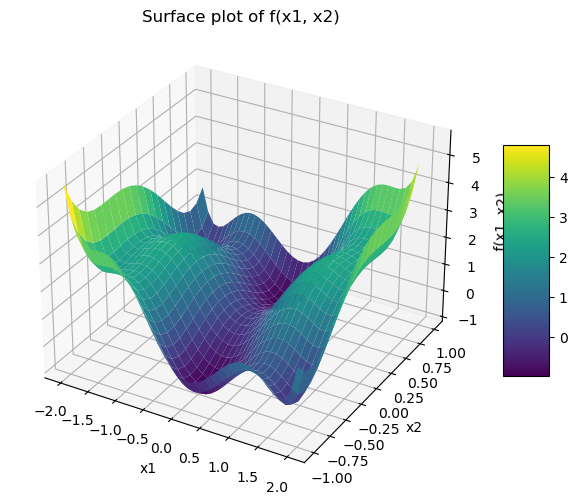

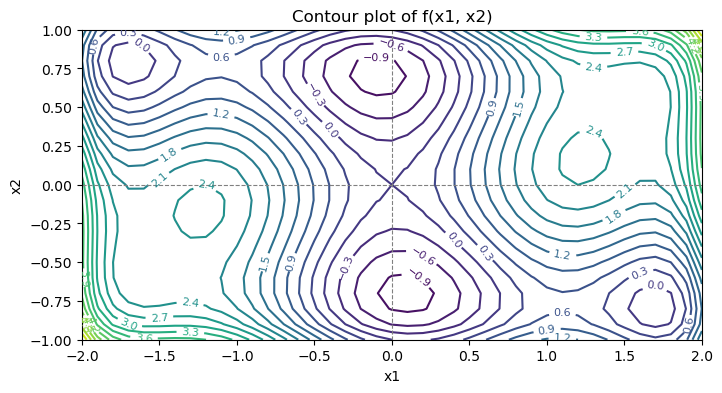

In [47]:
def plot_2d_function(f, x1_range, x2_range, step=0.1, cmap="viridis"):

    # Define the grid
    x1 = np.arange(x1_range[0], x1_range[1] + step, step)
    x2 = np.arange(x2_range[0], x2_range[1] + step, step)
    X1, X2 = np.meshgrid(x1, x2)
    Z = f(X1, X2)

    # 3D Surface Plot
    fig1 = plt.figure(figsize=(8, 6))
    ax = fig1.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap=cmap, edgecolor='none')
    ax.set_title("Surface plot of f(x1, x2)")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("f(x1, x2)")
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

    # Contour Plot
    plt.figure(figsize=(8, 6))
    contour = plt.contour(X1, X2, Z, levels=25, cmap=cmap)
    plt.clabel(contour, inline=True, fontsize=8)
    plt.title("Contour plot of f(x1, x2)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


def f2(x1, x2):
    return (x1**2)*(4 - 2.1*(x1**2) + (1.0/3.0)*(x1**4)) + x1*x2 + (x2**2)*(-4 + 4*(x2**2))

plot_2d_function(f2, x1_range=(-2, 2), x2_range=(-1, 1))

S'obtindran diversos mínim però obviament el mínim que s'obtindrà depen del punt inicial on comence el mètode.

Perform the next tests:

---

**1.** Assume that we follow the simple gradient descent with 100 iterations:

$$
\mathbf{x}^{\,k+1} = \mathbf{x}^{\,k} - \alpha^k \nabla f\!\left(\mathbf{x}^{\,k}\right)
$$

Using the plot found at step 1, try to start at different starting points $\mathbf{x}^0$ using $\alpha^k = 0.1$ (within the range $x_1 \in [-2, 2]$ and $x_2 \in [-1, 1]$). Draw the path the minimization algorithm follows and observe to which minimum the algorithm converges. You should see that, for a given starting point $\mathbf{x}^0$, the algorithm usually converges to the minimum located in the **valley** to which $\mathbf{x}^0$ belongs.

In [48]:
# Gradient descens method with constant learning rate

## definim el nou el gradient però ara que retorne un vector
def grad_f2(x1, x2):

    grad_x1 = x2 + 8 * x1 - 8.2 * x1**3 + 2 * x1**5
    grad_x2 = x1 - 8 * x2 + 16 * x2**3

    return np.array([grad_x1, grad_x2])


## definim el proces del grad descens però ara el gradient forma part de la funció per fer-la adaptativa
def grad_desc_cte2(grad_f, x0, alpha,niter):
    xk = x0
    fpath = [x0]

    for i in range(0,niter):
        xk = xk - np.array([alpha,alpha]) * grad_f(xk[0], xk[1])
        fpath.append(xk)
    
    return(fpath)


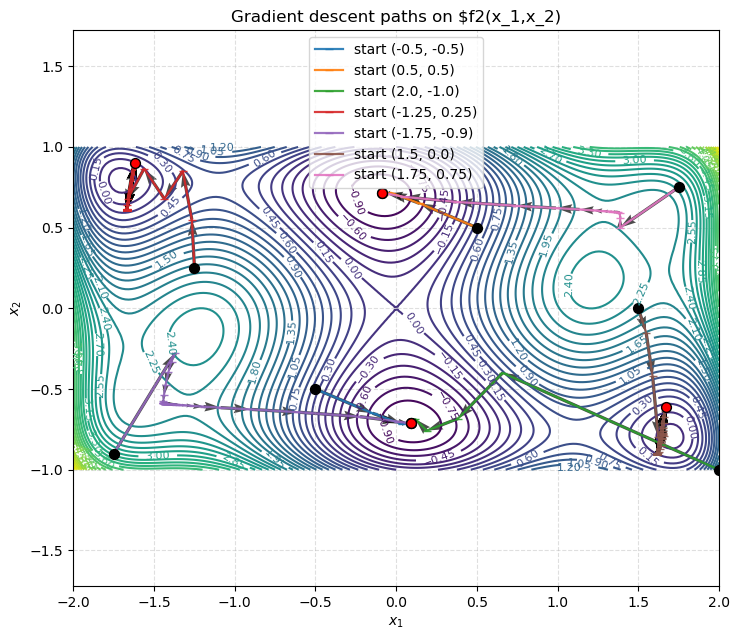

In [49]:
f2path1 = grad_desc_cte2(grad_f2, x0 = np.array([-0.5,-0.5]), alpha = 0.1, niter = 100)
f2path2 = grad_desc_cte2(grad_f2, x0 = np.array([0.5,0.5]), alpha = 0.1, niter = 100)
f2path3 = grad_desc_cte2(grad_f2, x0 = np.array([2,-1]), alpha = 0.1, niter = 100)
f2path4 = grad_desc_cte2(grad_f2, x0 = np.array([-1.25,0.25]), alpha = 0.1, niter = 100)
f2path5 = grad_desc_cte2(grad_f2, x0 = np.array([-1.75,-0.9]), alpha = 0.1, niter = 100)
f2path6 = grad_desc_cte2(grad_f2, x0 = np.array([1.5,0]), alpha = 0.1, niter = 100)
f2path7 = grad_desc_cte2(grad_f2, x0 = np.array([1.75,0.75]), alpha = 0.1, niter = 100)

# Representació 

paths  = [f2path1, f2path2, f2path3, f2path4, f2path5, f2path6, f2path7]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

# --- malla per al contorn ---
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-1, 1, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = f2(X1, X2)

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.005, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)

# mínim global
#plt.scatter(0, 0, s=90, marker='.', color='lime', edgecolor='lime', zorder=4)

plt.title(r"Gradient descent paths on $f2(x_1,x_2)")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
# FORÇAR RANG EXACTE DEL DOMINI DEFINIT
plt.xlim(-2, 2)
plt.ylim(-1, 1)
plt.axis('equal')

plt.show()


2. Let us perform an improvement to the previous algorithm. Indeed, until now we have considered a constant value for $\alpha^k$. Let us now consider adapting the value of $\alpha^k$ at each iteration. 

There are many algorithms that try to compute a good value of $\alpha^k$. In general, you are recommended to use algorithms that implement, for instance, the **Armijo rule**  (the definition of the rule will be given in the lectures). The advantage of the latter algorithms is that they find much better values for $\alpha^k$ than the simple backtracking algorithm you are going to implement next.

The **backtracking algorithm** works quite well in many cases. Assume that $\mathbf{x}^k$ and $\nabla f(\mathbf{x}^k)$ have been computed. In order to compute $\mathbf{x}^{k+1}$ we start (at each iteration $k$) with $\alpha^k = 1$ and perform the next inner loop iterations:

**(a)** Check if 
$$
f\bigl(\mathbf{x}^k - \alpha^k \nabla f(\mathbf{x}^k)\bigr) < f(\mathbf{x}^k).
$$  
This condition checks if the proposed value of $\alpha^k$ reduces the value of $f(\mathbf{x}^k)$.


**(b)** If (a) is not satisfied, update $\alpha^k = \alpha^k / 2$, for instance. That is, the step is divided by 2.  Go to step (a) and check again.

If (a) is satisfied, perform the update $\mathbf{x}^{k+1} = \mathbf{x}^k - \alpha^k \nabla f(\mathbf{x}^k)$ and start again the algorithm by computing $\nabla f(\mathbf{x}^{k+1})$ with $\alpha^{k+1} = 1$.

There are several convergence criteria that may be used to check the algorithm has found the minimum. For instance, if $|\, f(\mathbf{x}^{k+1}) - f(\mathbf{x}^k) \,|$ or $\|\, \nabla f(\mathbf{x}^{k+1}) \,\|$ is below a certain threshold (or if $\alpha^k$ reduces below a certain threshold), you may conclude that the gradient descent has converged. You have found the minimum (up to a certain precision)!

The previous algorithm shows the principles of the backtracking algorithm: the idea is to compute $\alpha^k$ by progressively reducing its value until you ensure that the value of $f$ is reduced. You may find several improvements to the algorithm, although this is not the purpose of the practical.

Implement the previous algorithm. Rather than using 100 iterations, perform the necessary number of iterations $k$ until you find an optimal iteration $k$ for which the convergence criterion is satisfied, e.g. $\|\, \nabla f(\mathbf{x}^{k+1}) \,\| < 10^{-5}$ (or $|\, f(\mathbf{x}^{k+1}) - f(\mathbf{x}^k) \,| < 10^{-3}$). How does the algorithm perform as compared with the constant step results? How many iterations are needed to reach the minimum? 100? Or may be less? There is no single right answer to this question. Just experiment a little bit!



In [50]:
import numpy as np

# Adaptem les funcions anterior per facilitar l'escriptura
def f2_adap(x):
    x1 = x[0]
    x2 = x[1]
    return (x1**2)*(4 - 2.1*(x1**2) + (1.0/3.0)*(x1**4)) + x1*x2 + (x2**2)*(-4 + 4*(x2**2))

def grad_f2_adap(x):
    x1 = x[0]
    x2 = x[1]

    grad_x1 = x2 + 8 * x1 - 8.2 * x1**3 + 2 * x1**5
    grad_x2 = x1 - 8 * x2 + 16 * x2**3

    return np.array([grad_x1, grad_x2])


# Backtraking algorithm (convergence criterion ||gradeint|| < 10^-5 )
def backtraking(f, grad_f, x0):

    xk = x0
    alpha_k = 1
    fpath = [x0]
    grad_xk = grad_f(xk)

    while np.linalg.norm(grad_xk) > 10**(-5): 
         
         while f(xk - alpha_k * grad_xk) >= f(xk):
             alpha_k = alpha_k / 2
            
         xk = xk - alpha_k * grad_f(xk)
         grad_xk = grad_f(xk)
         fpath.append(xk)
    
    print("BACKTRACKING ALGORITHM \n----------------------")
    print("Punt inicial: (", x0[0], ",", x0[1], ")")
    print("Punt final: (", np.round(xk[0],4), ",", np.round(xk[1],4), ")")
    print("Número passos fins assolir el mínim: ", np.size(fpath))

    return(fpath)
    

path1 = backtraking(f = f2_adap, grad_f = grad_f2_adap, x0 = np.array([-1.75,-0.9]))
print("Gradient descent (learning rate constant) mateixes iteracions", np.round(f2path5[30],4))

np.size(path1)

BACKTRACKING ALGORITHM 
----------------------
Punt inicial: ( -1.75 , -0.9 )
Punt final: ( -0.0898 , 0.7127 )
Número passos fins assolir el mínim:  30
Gradient descent (learning rate constant) mateixes iteracions [-1.4219 -0.5912]


30

### The Rosenbrock function

Let us consider the Rosenbrock function, see figure 2. The function is defined as

$$
f(x_1, x_2) = (a - x_1)^2 + b \, (x_2 - x_1^2)^2
$$

The function has a global minimum at $(x_1^*, x_2^*) = (a, a^2)$, where $f(x_1^*, x_2^*) = 0$. The global minimum is inside a long, very narrow, parabolic shaped valley. The convergence to the global minimum is difficult. There are no local minimums.

You are asked to perform the next experiments:

1. Plot the contours of the Rosenbrock function for $a = 1$ and $b = 100$. The minimum of the function is thus at $(x_1^*, x_2^*) = (1, 1)$. You may also draw the gradient information.

2. Try different starting points $\mathbf{x}^0$ in order to check the robustness of the backtracking descent algorithm you have implemented. Draw the path the gradient descent follows in order see how good your algorithm performs. You may stop the algorithm as soon as the stopping criterion is satisfied, e.g.

   $$
   \left\| \nabla f(\mathbf{x}^{k+1}) \right\| < 10^{-5}
   \quad \text{(or} \quad
   \left| f(\mathbf{x}^{k+1}) - f(\mathbf{x}^{k}) \right| < 10^{-3} \text{).}
   $$
   Do not limit the iterations to 100. How many iterations are performed until the stopping criterion is satisfied?

The fact that the stopping criterion is satisfied does not necessary imply that the minimum has been reached. Once the stopping criterion is satisfied, just check the values of $x_1$ and $x_2$ the algorithm has been able to find. Is the algorithm able to reach the minimum? Recall that we know the minimum which is $(x_1^*, x_2^*) = (1, 1)$.

If the stopping criterion is not able to find the minimum, modify the criterion (by putting lower thresholds, for instance) to see if it is able to find the minimum. Just test if you are able to find the minimum!


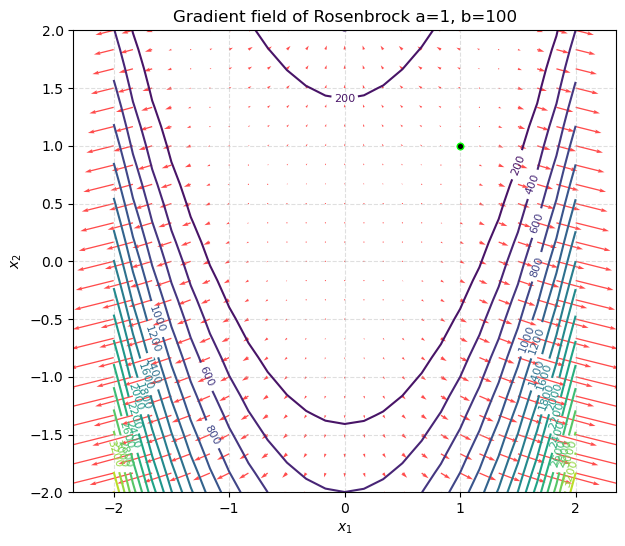

In [51]:
a = 1
b = 100

def rosenbrock(x1, x2):
    return((a-x1)**2 + b*(x2-x1**2)**2)

def grad_rosenbrock(x1, x2):
    grad_x1 = -2*(a-x1) - 4*b*x1*(x2-x1**2)
    grad_x2 = 2*b*(x2-x1**2)
    return grad_x1, grad_x2


x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)


Z = rosenbrock(X1, X2)
U, V = grad_rosenbrock(X1, X2)


plt.figure(figsize=(7,6))
contours = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.quiver(X1, X2, U, V, color='red', alpha=0.7)
plt.scatter(1, 1, s=90, marker='.', color='black', edgecolor='lime', zorder=4)

plt.title(r"Gradient field of Rosenbrock a=1, b=100")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid(True, linestyle='--', alpha=0.4)
plt.axis("equal")
plt.show()

BACKTRACKING ALGORITHM 
----------------------
Punt inicial: ( -1.8 , -1.5 )
Punt final: ( 1.0 , 1.0 )
Número passos fins assolir el mínim:  52520


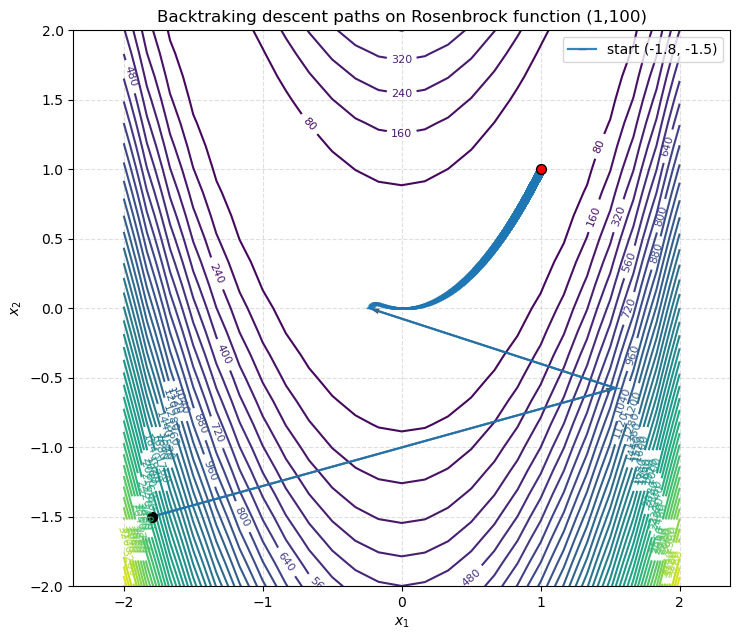

In [52]:
# Adaptacions
def rosenbrock_adap(x):
    x1 = x[0]
    x2 = x[1]
    return((a-x1)**2 + b*(x2-x1**2)**2)

def grad_rosenbrock_adap(x):
    x1 = x[0]
    x2 = x[1]
    grad_x1 = -2*(a-x1) - 4*b*x1*(x2-x1**2)
    grad_x2 = 2*b*(x2-x1**2)
    return np.array([grad_x1, grad_x2])


a = 1
b = 100

rpath1 = backtraking(f = rosenbrock_adap, grad_f = grad_rosenbrock_adap, x0 = np.array([-1.8,-1.5]))


# Representació 

paths  = [rpath1]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)

Z = rosenbrock(X1, X2)
U, V = grad_rosenbrock(X1, X2)

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.003, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)


plt.title(r"Backtraking descent paths on Rosenbrock function (1,100)")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('equal')
plt.show()

In [53]:
## Newton descent method

### A simple quadratic function

1. 

1.0

In [54]:
def f3(x):
    x1 = x[0]
    x2 = x[1]
    return(100*x1**2 + x2**2)

def grad_f3(x):
    x1 = x[0]
    x2 = x[1]
    grad_x1 = 100*2*x1
    grad_x2 = 2*x2
    return np.array([grad_x1, grad_x2])

f3path1 = backtraking(f = f3, grad_f = grad_f3, x0 = np.array([-0.5,1]))


BACKTRACKING ALGORITHM 
----------------------
Punt inicial: ( -0.5 , 1.0 )
Punt final: ( -0.0 , 0.0 )
Número passos fins assolir el mínim:  1554


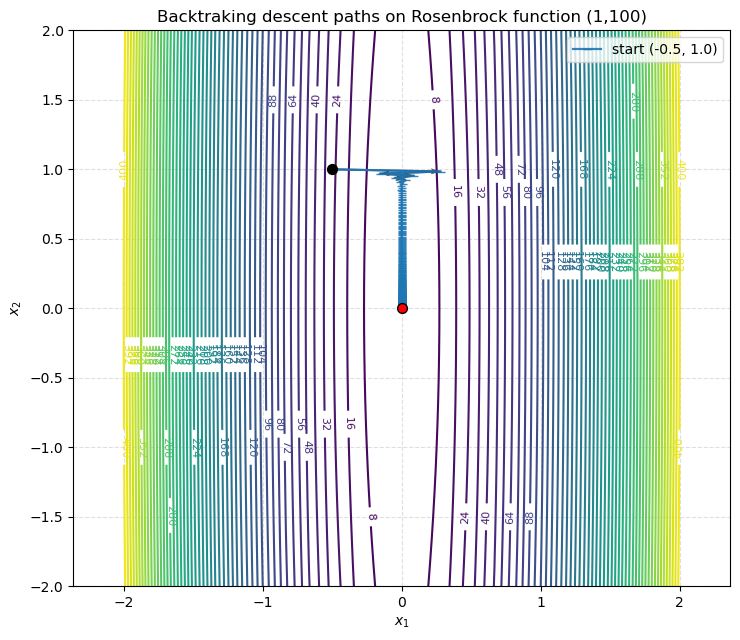

In [55]:
# Representació 

paths  = [f3path1]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)

Z = f3([X1, X2])
U, V = grad_f3([X1, X2])

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.003, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)


plt.title(r"Backtraking descent paths on Rosenbrock function (1,100)")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('equal')
plt.show()

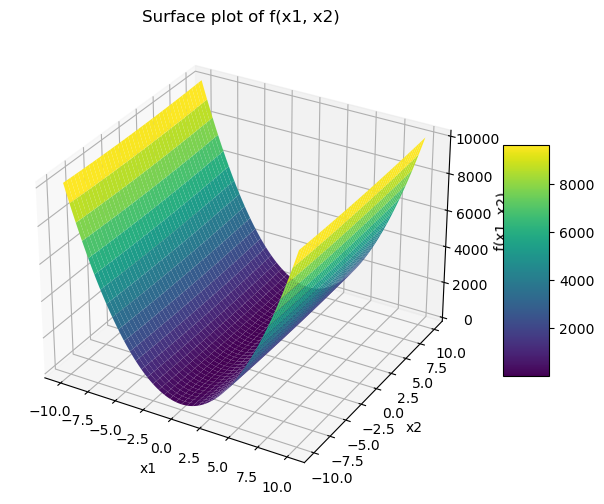

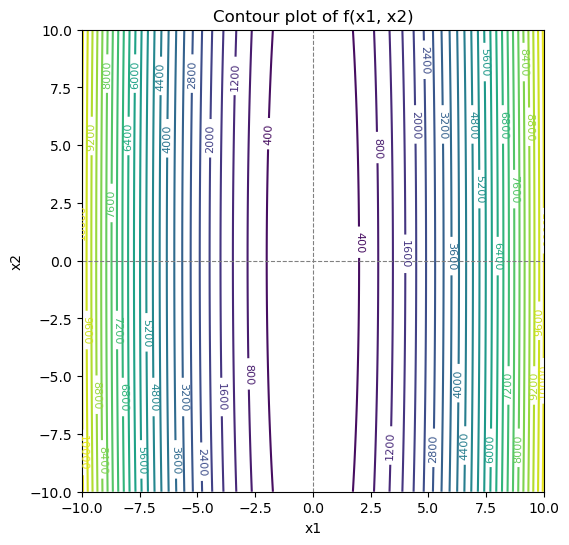

In [56]:
def f3_extra(x1,x2):
    return(100*x1**2 + x2**2)

def plot_2d_function(f, x1_range, x2_range, step=0.1, cmap="viridis"):

    # Define the grid
    x1 = np.arange(x1_range[0], x1_range[1] + step, step)
    x2 = np.arange(x2_range[0], x2_range[1] + step, step)
    X1, X2 = np.meshgrid(x1, x2)
    Z = f(X1, X2)

    # 3D Surface Plot
    fig1 = plt.figure(figsize=(8, 6))
    ax = fig1.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X1, X2, Z, cmap=cmap, edgecolor='none')
    ax.set_title("Surface plot of f(x1, x2)")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel("f(x1, x2)")
    plt.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

    # Contour Plot
    plt.figure(figsize=(8, 6))
    contour = plt.contour(X1, X2, Z, levels=25, cmap=cmap)
    plt.clabel(contour, inline=True, fontsize=8)
    plt.title("Contour plot of f(x1, x2)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()


plot_2d_function(f3_extra, x1_range=(-10, 10), x2_range=(-10, 10))

In [76]:
H = np.array([[200,0],[0,2]])


# Newton (convergence criterion ||gradient|| < 10^-5 )
def newton(f, grad_f, H, x0):

    xk = x0
    alpha_k = 1
    fpath = [x0]
    grad_xk = grad_f(xk)
    inversa = np.linalg.inv(H)
    dk = - np.matmul(inversa, grad_xk)

    while np.linalg.norm(grad_xk) > 10**(-5): 

         while f(xk + alpha_k * dk) >= f(xk):
             alpha_k = alpha_k / 2
            
         xk = xk + alpha_k * dk
         grad_xk = grad_f(xk)
         dk = - np.matmul(inversa, grad_xk)
         fpath.append(xk)
    
    print("NEWTON ALGORITHM \n----------------------")
    print("Punt inicial: (", x0[0], ",", x0[1], ")")
    print("Punt final: (", np.round(xk[0],4), ",", np.round(xk[1],4), ")")
    print("Número passos fins assolir el mínim: ", np.size(fpath))

    return(fpath)


f3path1 = newton(f = f3, grad_f = grad_f3, H=H, x0 = np.array([-0.5,1]))




NEWTON ALGORITHM 
----------------------
Punt inicial: ( -0.5 , 1.0 )
Punt final: ( 0.0 , 0.0 )
Número passos fins assolir el mínim:  4


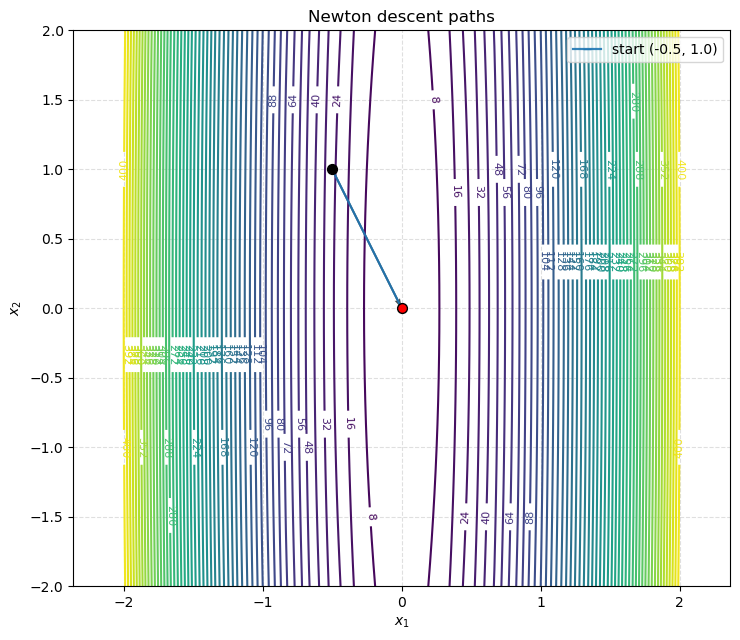

In [77]:
# Representació 

paths  = [f3path1]
labels = [f"start {tuple(np.array(p)[0])}" for p in paths]  # etiqueta automàtica

x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)

Z = f3([X1, X2])
U, V = grad_f3([X1, X2])

plt.figure(figsize=(7.5, 6.5))
cs = plt.contour(X1, X2, Z, levels=50)
plt.clabel(cs, inline=True, fontsize=8)

# --- dibuixa cada camí ---
for path, lab in zip(paths, labels):
    P = np.asarray(path, dtype=float)        # (k,2)
    # línia i punts
    plt.plot(P[:,0], P[:,1], marker='_', linewidth=1.6, label=lab, alpha=0.9)
    # fletxes entre iteracions
    d = P[1:] - P[:-1]
    plt.quiver(P[:-1,0], P[:-1,1], d[:,0], d[:,1],
               angles='xy', scale_units='xy', scale=1, width=0.003, alpha=0.7)
    # marca inici i final
    plt.scatter(P[0,0],  P[0,1],  s=50, edgecolor='k', facecolor='black',  zorder=3)
    plt.scatter(P[-1,0], P[-1,1], s=50, edgecolor='k', facecolor='red',   zorder=3)


plt.title(r"Newton descent paths")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.tight_layout()
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('equal')
plt.show()